Code for generating unjamming simulations (figure 5) for different jam widths and depths (two commented blocks for replicates; first is for width+depth, second for width only; 
setup periodic in x and y, but y limits are very large so it's practically unbounded in y

# FSM

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from matplotlib.animation import FuncAnimation
import matplotlib.patches as patches
from math import cos, sin, pi
from IPython.display import HTML, Video, display

"""
-----------------------
Helper Functions: Later move it to another file.py
-----------------------

"""
def selfPropulsionForce(m, tau, desiredSpeed, desiredDirection, velocity):
    desiredVelocity = desiredSpeed * desiredDirection
    return (desiredVelocity - velocity) * (m / tau)

def interactionForce(position, R, A, B, Lx, Ly):
    N = position.shape[0]
    epsilon = 1e-6 # Used to avoid infinity
    agent_size = 2 * R

    x = position[:, 0].reshape(-1, 1)
    y = position[:, 1].reshape(-1, 1)

    dx = x - x.T
    dy = y - y.T


    dx_u = dx - np.round(dx / Lx) * Lx
    dy_u = dy - np.round(dy / Ly) * Ly

    # Euclidean distance calculation
    dist = np.sqrt(dx_u**2 + dy_u**2)
    
    valid_index = (dist < (3*R)) & (dist > 0)

    # Unit vectors
    dij_x = np.zeros_like(dist)
    dij_y = np.zeros_like(dist)
    np.divide(dx_u, dist, out=dij_x, where=dist>epsilon)
    np.divide(dy_u, dist, out=dij_y, where=dist>epsilon)   
    # np.divide(dx_u, dist+epsilon, out=dij_x)#, where=dist>epsilon)
    # np.divide(dy_u, dist+epsilon, out=dij_y)#, where=dist>epsilon)
    
    # Apply valid_index mask
    dij_x[~valid_index] = 0
    dij_y[~valid_index] = 0
    
    # Effective distance
    effective_dist = np.maximum(dist - agent_size, epsilon)
    
    # Force magnitude calculation
    force_magnitude = np.zeros_like(dist)
    np.power(effective_dist, -B, out=force_magnitude, where=effective_dist>epsilon)
    force_magnitude *= -A
    
    force_magnitude[~valid_index] = 0

    interaction_force = np.column_stack((np.sum(force_magnitude * dij_x, axis=0),np.sum(force_magnitude * dij_y, axis=0)))

    return interaction_force


In [2]:
# Imports and Initializations
import numpy as np
import matplotlib.pyplot as plt

from parfor import parfor
import csv
from tqdm import tqdm

In [3]:
# Setting model parameters


def periodify(pos,Lx,Ly):
    if len(pos.shape)==1:
        pos[0]=pos[0]%Lx
        pos[1]=pos[1]%Ly
    else:
        pos[:,0]=pos[:,0]%Lx
        pos[:,1]=pos[:,1]%Ly
    return pos



def getdisp(a,b):
    disp=a-b
    if len(disp.shape)==1:
        disp[0]=disp[0]-np.round(disp[0]/Lx)*Lx
        disp[1]=disp[1]-np.round(disp[1]/Ly)*Ly
    else:
        disp[:,0]=disp[:,0]-np.round(disp[:,0]/Lx)*Lx
        disp[:,1]=disp[:,1]-np.round(disp[:,1]/Ly)*Ly
    return disp





In [4]:
def updatepos(agentpos,agentdir,v):
    return periodify(agentpos+np.array([v*np.cos(agentdir),v*np.sin(agentdir)]),Lx,Ly)

def getstate(agentposdir, agent, othersposes,grad):
    return tuple([0,0,np.round(agentposdir[0][0],6),np.round(agentposdir[0][1],6)]+[np.round(np.exp(grad) if grad<0 else 1+np.log(1+grad),6)])


def getbest(stateslists):
    outs=[]
    for statelist in stateslists:
        statematrix=np.array(statelist)
        if statematrix.shape[0]==0:
            score=-1
        else:
            gradmat=statematrix[:,-1]
            statematrix=statematrix[:,:-4]
            score=gradmat.sum()
        outs.append(score)
    return randargmax(np.array(outs))
    
def randargmax(b):
    return np.random.choice(np.where(b == b.max())[0])

def intervallen(inter):
    length=0
    for i in inter:
        length+=i.upper-i.lower
    return length


def findposesovertime(agentsposes,agentsdirs,agentsvels,tau_fut):
    # return [np.ones_like(agentsposes)*80]*(1+tau_fut)
    posesovertime=[]
    posesovertime.append(agentsposes)
    newposes=agentsposes.copy()
    newdirs=agentsdirs.copy()
    for i in range(tau_fut):
        newposes=newposes+agentsvels.reshape(-1,1)*np.vstack([np.cos(newdirs),np.sin(newdirs)]).T
        # for agent in range(numagents):
        newpos,newdirs=(newposes.copy(),newdirs)
        posesovertime.append(periodify(newpos,Lx,Ly))
    return posesovertime



# def findposesovertime(agentsposes,agentsdirs,agentsvels,tau_fut):
#     agentsvels=np.vstack((agentsvels*np.cos(agentsdirs),agentsvels*np.sin(agentsdirs))).T
#     numagents=len(agentsposes)
#     v0=agentsvels-calcphi(agentsposes,agentsvels)
#     posesovertime=[agentsposes]
#     newposes=agentsposes.copy()
#     newvels=agentsvels.copy()
#     newposes=newposes+newvels
#     newposes,newdirs=(newposes,agentsdirs)
#     posesovertime.append(periodify(newposes.copy(),Lx,Ly))
#     for t in range(2,tau_fut+1):
#         newvels=calcphi(newposes,newvels)+v0
#         newdirs=np.arctan2(newvels[:,1],newvels[:,0])
#         newposes=newposes+newvels
#         newposes,newdirs=(newposes,newdirs)
#         posesovertime.append(periodify(newposes.copy(),Lx,Ly))
#     return posesovertime

# def calcphi(agentsposes,agentsvels):
#     mu=1
#     interboundary=3*agentradius
#     xposes=agentsposes[:,0].reshape(-1,1)
#     yposes=agentsposes[:,1].reshape(-1,1)
#     xdisps=(xposes.T-xposes)
#     xdisps=xdisps - np.round(xdisps / Lx) * Lx
#     ydisps=yposes.T-yposes
#     ydisps=ydisps - np.round(ydisps / Ly) * Ly
#     dists=(xdisps**2+ydisps**2)**0.5-np.eye(numagents)
#     interactings=(dists<interboundary)*(dists>=0)
#     interactings2=np.zeros_like(interactings)
#     interactings2[interactings]=interboundary/dists[interactings]
#     xdisps=xdisps/dists
#     ydisps=ydisps/dists
#     disps=np.array([xdisps,ydisps])
#     phi=np.einsum('jd,dji,sji,ij->is',agentsvels,disps,disps,interactings2)
#     interactings2=interactings2.sum(axis=1)
#     phi[interactings2>0,:]=phi[interactings2>0,:]/interactings2[interactings2>0].reshape(-1,1)
#     return phi



def rightdiff(a,b):
    if b>a:
        return a+2*np.pi-b
    else: return a-b


def make_moveset(agentpos,agentdir,v):
    dircombs=[(agentdir+deltheta)%(2*np.pi),agentdir,(agentdir-deltheta)%(2*np.pi),(agentdir-2*deltheta)%(2*np.pi),(agentdir+2*deltheta)%(2*np.pi)]
    # dircombs=[(agentdir+deltheta)%(2*np.pi),agentdir,(agentdir-deltheta)%(2*np.pi)]
    # dircombs = [i for i in np.arange(0,2*np.pi-0.0001,np.pi/5)]
    # tempvelcombs=[v-delv,v,v+delv]
    # velcombs=[]
    # for vel in tempvelcombs:
    #     if vel>=minvel and vel<=maxvel:
    #         velcombs.append(vel)
    velcombs=[v]
    moveset=[]
    for vel in velcombs:
        for dir in dircombs:
            moveset.append([vel,dir])
    return moveset


def reflect_nearest(agentpos,agent,othersposes):
    disps=getdisp(othersposes,agentpos)
    disps=np.delete(disps,agent,axis=0)
    dists=((disps**2).sum(axis=1))**0.5
    minarg=dists.argmin()
    if dists[minarg]<2*R:
        mag=2*R-dists[minarg]
        dir=np.arctan2(-disps[minarg][1],-disps[minarg][0])
        newpos=agentpos+[2*mag*np.cos(dir),2*mag*np.sin(dir)]
        return (periodify(newpos,Lx,Ly),dir)[0]
    return agentpos
        
def randevolve(numsamp,agentpos,agentdir, agent, othersposesovertime, move, k,tau_fut,velprobs,thetprobs):
    v=1 ##################### this was move[0] before
    outposes=[]
    ogpos=agentpos
    # othersposes=othersposesovertime[0]
    othersposes=othersposesovertime[1]
    newagentdir=(move[1])%(2*np.pi)
    newagentposdir=[reflect_nearest(updatepos(agentpos,newagentdir,v),agent,othersposes),newagentdir]
    for samp in range(numsamp):
        newpos,newdir=newagentposdir.copy()
        # a,b=newpos.copy(),newdir
        for t in range(2,tau_fut+1):
            newdir=newdir+np.random.choice([-deltheta,-2*deltheta,0,deltheta,2*deltheta])#,p=thetprobs)
            # newdir=np.random.choice([i for i in np.arange(0,2*np.pi-0.0001,np.pi/5)])
            newpos=reflect_nearest(updatepos(newpos,newdir,v),agent,othersposesovertime[t])
        outposes.append(getstate([newpos,newdir],agent,othersposesovertime[t],getdisp(newpos,ogpos)@np.array([np.cos(desired[agent]),np.sin(desired[agent])])))
    return outposes


# Parallel

In [5]:
from tqdm import tqdm
import pickle


deltaT = 0.005
timeStep = 35000
totalTime = deltaT*timeStep


Ly=19

R = 1
m = 1
A = 0.01
B = 3
tau = 1


updateT=tau
updateF=round(updateT/deltaT)



Nr = 1/2
deltheta=np.pi/8

tau_fut=6
agentradius=R

numsamp=50





# number of agent in each group



In [18]:
# # Initial Position
# for rows in [8]:
#     for columns in [12,14]:
#         # N=16*20
#         # Lx=100
#         # Ly=40
#         N=rows*columns
#         Lx=5*columns
#         Ly=19*rows/10
#         numagents=N
#         g1 = int(round(N * Nr))
#         g2 = N - g1
#         for rep in range(3):
#             xData = []
#             yData = []
#             uData = []
#             vData = []
#             desdirs=[]
#             forces=[]
        
            
#             # position=np.array(sum([[[x,y] for y in [1.9,5.7,9.5,13.3,17.1]] for x in [2,4.5,7,9.5,12,14.5,17,19.5]],[]))#[np.random.permutation(np.arange(N))]
#             # position=np.array(sum([[[x,y] for y in [1.5,5.5,9.5,13.5,17.5,21.5,25.5,29.5,33.5,36]] for x in np.arange(2,80,2.5)],[]))#[np.random.permutation(np.arange(N))]
#             position=np.array(sum([[[x,y] for y in [1.5,5.5,9.5,13.5,17.5,21.5,25.5,29.5,33.5,36][:rows//2]] for x in np.arange(2,Lx,2.5)],[]))#[np.random.permutation(np.arange(N))]
#             # position=np.array(sum([[[x,y] for y in [1,5.5]] for x in [2,4.5,7,9.5,12,14.5,17,19.5,22,24.5,27,29.5]],[]))
#             # position=np.array(sum([[[x,y] for y in [1.25,3.75,6.25,8.75,11.25,13.75,16.25,18.75]] for x in [2,4.5,7,9.5,12,14.5,17,19.5]],[]))[np.random.permutation(np.arange(N))]
#             # position=np.array([[4,4],[17,4]])
#             # position=np.array([[4.5,9.5]]+sum([[[x,y] for y in [1.5,5.5,9.5,13.5,17.5]] for x in [12,14.5,17,19.5]],[]))
#             # position=np.array([[3,10]]+list(np.random.random(size=(5,2))*18)+[[17,10]])
#             # position=startpos.copy()[np.random.permutation(np.arange(90))]
#             # position=position+(np.random.random(size=position.shape)-0.5)*0.001
#             position[:g1,1]=position[:g1,1]+0.001
#             # position[g1:,0]=position[g1:,0]+5
#             # Lx+=5
#             position[:,0]=position[:,0]%Lx
#             position[:,1]=position[:,1]%Ly
            
#             # Initial Speed
#             # speed = np.array([1,1]).reshape(-1,1)
#             speed=0
            
#             # Initial Direction
#             theta = np.random.uniform(0, 2* np.pi, size = (N, 1))
#             # theta=np.array([0,np.pi/2]).reshape(-1,1)
#             # theta = np.ones(shape=(N,1))*np.pi/2
#             # print(theta)
#             # Parameter for force calculation
            
            
#             # Inital velocity
#             velocity = speed * np.column_stack((np.cos(theta), np.sin(theta)))
            
#             # Desired speed
#             desiredSpeed = np.ones((N,1)) * 1
#             # desiredSpeed[:g1] = 0
            
            
#             # Desired direction
#             desiredDirectionA = np.ones((N, 1))
#             desiredDirectionA[:g1] = 0
#             desiredDirectionA[g1:] = np.pi
#             desired=(desiredDirectionA.copy()).ravel()
#             desiredDirection = np.hstack((np.cos(desiredDirectionA), np.sin(desiredDirectionA)))
        
        
#             # ############################################################
        
#             # file=glob('./40agents_nofsm/*_11_*.pickle')[0]
#             # with open(file,'rb') as f:
#             #     alldat=pickle.load(f)
#             #     position=np.vstack([alldat['xData'][0],alldat['yData'][0]]).T
#             #     velocity=np.vstack([alldat['uData'][0],alldat['vData'][0]]).T
        
#             # ############################################################
            
#             xData.append(position[:,0])
#             yData.append(position[:,1])
            
#             uData.append(velocity[:,0])
#             vData.append(velocity[:,1])
            
            
            
            
            
#             for t in tqdm(range(timeStep)):
#                 if t*deltaT>35:
#                     if t%updateF==updateF-1:
#                         # print(t)
#                         agentsposes=position
#                         agentsdirs=np.arctan2(velocity[:,1],velocity[:,0])%(2*np.pi)
#                         agentsvels=updateT*((velocity[:,1])**2+(velocity[:,0])**2)**0.5
#                         agentsposesovertime=findposesovertime(agentsposes,agentsdirs,agentsvels,tau_fut)
#                         # print(time)
#                         chosenmoves=[]
#                         @parfor(range(numagents),bar=False)
#                         def paragent(focal):
#                             stateslists=[]
#                             agentpos=agentsposes[focal]
#                             agentdir=agentsdirs[focal]
#                             agentvel=agentsvels[focal]
#                             moveset=make_moveset(agentpos,agentdir,agentvel)
#                             for move in moveset:
#                                 evolvelist=randevolve(numsamp,agentpos,agentdir,focal,agentsposesovertime,move,1,tau_fut,[1/3]*3,[1/5]*5)
#                                 stateslists.append(evolvelist)
#                             chosen=getbest(stateslists)
#                             return moveset[chosen]
#                         chosenmoves=np.array(paragent)
#                         # desiredSpeed=chosenmoves[:,0].reshape(-1,1)
#                         desiredDirectionA=(chosenmoves[:,1]).reshape(-1,1)
#                         desiredDirection = np.hstack((np.cos(desiredDirectionA), np.sin(desiredDirectionA)))
#                 desdirs.append(desiredDirection[:].copy())
#               # Force calculation
#                 f1 = selfPropulsionForce(m, tau, desiredSpeed, desiredDirection, velocity)#*np.random.normal(0,1,size=(N,2))
#                 f2 = interactionForce(position, R, A, B, Lx,Ly)
#                 force = (f1+f2)/m
        
#                 newPosition = position + (velocity * deltaT) + (0.5 * force * deltaT**2)
#                 newPosition[:,0] = (newPosition[:,0]) % Lx
#                 newPosition[:,1] = (newPosition[:,1]) % Ly
            
        
#                 deltaV = force * deltaT
            
#                 vint = velocity + deltaV
            
#                 f1_new = selfPropulsionForce(m, tau, desiredSpeed, desiredDirection, vint) 
#                 f2_new =  interactionForce(newPosition, R, A, B, Lx,Ly)
                
#                 forceNew = (f1_new + f2_new)/m
                
#                 newVelocity = velocity + (0.5 * (force + forceNew)) * deltaT
            
#                 velocity = newVelocity
#                 position = newPosition
                
        
#                 xData.append(newPosition[:,0])
#                 yData.append(newPosition[:,1])
                
#                 uData.append(newVelocity[:,0])
#                 vData.append(newVelocity[:,1])
#                 forces.append([f1,f2])
        
#             with open('./jam_width/'+str(rows)+'width'+str(N)+'_agents_withfsm_unjamming_35s_'+str(rep)+'_'+str(np.random.randint(10000))+'.pickle','wb') as file:
#             # with open('./200agents_withfsm/'+str(N)+'_agents_withfsm_randstart_'+str(rep)+'_'+str(np.random.randint(10000))+'.pickle','wb') as file:
#                 pickle.dump({'xData':xData,'yData':yData,'uData':uData,'vData':vData,'forces':forces,'desdirs':desdirs,'g1':g1,'Lx':Lx,'Ly':Ly,'N':N},file)#,'note':'tried to incorporate neighbor effects while predicting motion of other agents'},file)
    
    
        


100%|███████████████████████████████████████████████████████████████████████████| 35000/35000 [04:11<00:00, 139.38it/s]


In [15]:
# # Initial Position
# for columns in range(15,16):
#     N=columns*10
#     Lx=columns*5
#     Ly=29
#     numagents=N
#     g1 = int(round(N * Nr))
#     g2 = N - g1
#     for rep in range(1):
#         xData = []
#         yData = []
#         uData = []
#         vData = []
#         desdirs=[]
#         forces=[]
    
        
#         # position=np.array(sum([[[x,y] for y in [1.9,5.7,9.5,13.3,17.1]] for x in [2,4.5,7,9.5,12,14.5,17,19.5]],[]))#[np.random.permutation(np.arange(N))]
#         position=np.array(sum([[[x,y] for y in [1.5,5.5,9.5,13.5,17.5]] for x in np.arange(2,Lx,2.5)],[]))[np.random.permutation(np.arange(N))]
        
#         # position=np.array(sum([[[x,y] for y in [1.25,3.75,6.25,8.75,11.25,13.75,16.25,18.75]] for x in [2,4.5,7,9.5,12,14.5,17,19.5]],[]))[np.random.permutation(np.arange(N))]
#         # position=np.array([[4,4],[17,4]])
#         # position=np.array([[4.5,9.5]]+sum([[[x,y] for y in [1.5,5.5,9.5,13.5,17.5]] for x in [12,14.5,17,19.5]],[]))
#         # position=np.array([[3,10]]+list(np.random.random(size=(5,2))*18)+[[17,10]])
#         # position=startpos.copy()[np.random.permutation(np.arange(90))]
#         # position=position+(np.random.random(size=position.shape)-0.5)*0.001
#         position[:g1,1]=position[:g1,1]+0.001
#         # position[g1:,0]=position[g1:,0]+5
#         # Lx+=5
#         position[:,0]=position[:,0]%Lx
#         position[:,1]=position[:,1]%Ly
        
#         # Initial Speed
#         # speed = np.array([1,1]).reshape(-1,1)
#         speed=0
        
#         # Initial Direction
#         theta = np.random.uniform(0, 2* np.pi, size = (N, 1))
#         # theta=np.array([0,np.pi/2]).reshape(-1,1)
#         # theta = np.ones(shape=(N,1))*np.pi/2
#         # print(theta)
#         # Parameter for force calculation
        
        
#         # Inital velocity
#         velocity = speed * np.column_stack((np.cos(theta), np.sin(theta)))
        
#         # Desired speed
#         desiredSpeed = np.ones((N,1)) * 1
#         # desiredSpeed[:g1] = 0
        
        
#         # Desired direction
#         desiredDirectionA = np.ones((N, 1))
#         desiredDirectionA[:g1] = 0
#         desiredDirectionA[g1:] = np.pi
#         desired=(desiredDirectionA.copy()).ravel()
#         desiredDirection = np.hstack((np.cos(desiredDirectionA), np.sin(desiredDirectionA)))
    
    
#         # ############################################################
    
#         # file=glob('./40agents_nofsm/*_11_*.pickle')[0]
#         # with open(file,'rb') as f:
#         #     alldat=pickle.load(f)
#         #     position=np.vstack([alldat['xData'][0],alldat['yData'][0]]).T
#         #     velocity=np.vstack([alldat['uData'][0],alldat['vData'][0]]).T
    
#         # ############################################################
        
#         xData.append(position[:,0])
#         yData.append(position[:,1])
        
#         uData.append(velocity[:,0])
#         vData.append(velocity[:,1])
        
        
        
        
        
#         for t in tqdm(range(timeStep)):
#             if t*deltaT>35:
#                 if t%updateF==updateF-1:
#                     # print(t)
#                     agentsposes=position
#                     agentsdirs=np.arctan2(velocity[:,1],velocity[:,0])%(2*np.pi)
#                     agentsvels=updateT*((velocity[:,1])**2+(velocity[:,0])**2)**0.5
#                     agentsposesovertime=findposesovertime(agentsposes,agentsdirs,agentsvels,tau_fut)
#                     # print(time)
#                     chosenmoves=[]
#                     @parfor(range(numagents),bar=False)
#                     def paragent(focal):
#                         stateslists=[]
#                         agentpos=agentsposes[focal]
#                         agentdir=agentsdirs[focal]
#                         agentvel=agentsvels[focal]
#                         moveset=make_moveset(agentpos,agentdir,agentvel)
#                         for move in moveset:
#                             evolvelist=randevolve(numsamp,agentpos,agentdir,focal,agentsposesovertime,move,1,tau_fut,[1/3]*3,[1/5]*5)
#                             stateslists.append(evolvelist)
#                         chosen=getbest(stateslists)
#                         return moveset[chosen]
#                     chosenmoves=np.array(paragent)
#                     # desiredSpeed=chosenmoves[:,0].reshape(-1,1)
#                     desiredDirectionA=(chosenmoves[:,1]).reshape(-1,1)
#                     desiredDirection = np.hstack((np.cos(desiredDirectionA), np.sin(desiredDirectionA)))
#             desdirs.append(desiredDirection[:].copy())
#           # Force calculation
#             f1 = selfPropulsionForce(m, tau, desiredSpeed, desiredDirection, velocity)#*np.random.normal(0,1,size=(N,2))
#             f2 = interactionForce(position, R, A, B, Lx,Ly)
#             force = (f1+f2)/m
    
#             newPosition = position + (velocity * deltaT) + (0.5 * force * deltaT**2)
#             newPosition[:,0] = (newPosition[:,0]) % Lx
#             newPosition[:,1] = (newPosition[:,1]) % Ly
        
    
#             deltaV = force * deltaT
        
#             vint = velocity + deltaV
        
#             f1_new = selfPropulsionForce(m, tau, desiredSpeed, desiredDirection, vint) 
#             f2_new =  interactionForce(newPosition, R, A, B, Lx,Ly)
            
#             forceNew = (f1_new + f2_new)/m
            
#             newVelocity = velocity + (0.5 * (force + forceNew)) * deltaT
        
#             velocity = newVelocity
#             position = newPosition
            
    
#             xData.append(newPosition[:,0])
#             yData.append(newPosition[:,1])
            
#             uData.append(newVelocity[:,0])
#             vData.append(newVelocity[:,1])
#             forces.append([f1,f2])
    
#         with open('./jam_length/'+str(N)+'_agents_withfsm_unjamming_35s_'+str(rep)+'_'+str(np.random.randint(10000))+'.pickle','wb') as file:
#         # with open('./200agents_withfsm/'+str(N)+'_agents_withfsm_randstart_'+str(rep)+'_'+str(np.random.randint(10000))+'.pickle','wb') as file:
#             pickle.dump({'xData':xData,'yData':yData,'uData':uData,'vData':vData,'forces':forces,'desdirs':desdirs,'g1':g1,'Lx':Lx,'Ly':Ly,'N':N},file)#,'note':'tried to incorporate neighbor effects while predicting motion of other agents'},file)
    
    
        


In [ ]:
# import pickle
# with open('40_agents_withfsm','wb') as file:
#     pickle.dump({'xData':xData,'yData':yData,'uData':uData,'vData':vData,'forces':forces,'desdirs':desdirs},file)#,'note':'tried to incorporate neighbor effects while predicting motion of other agents'},file)

# alldata={'xData':xData,'yData':yData,'uData':uData,'vData':vData,'forces':forces,'desdirs':desdirs,'note':'tried to incorporate neighbor effects while predicting motion of other agents'}

# plots

In [94]:
g1

14

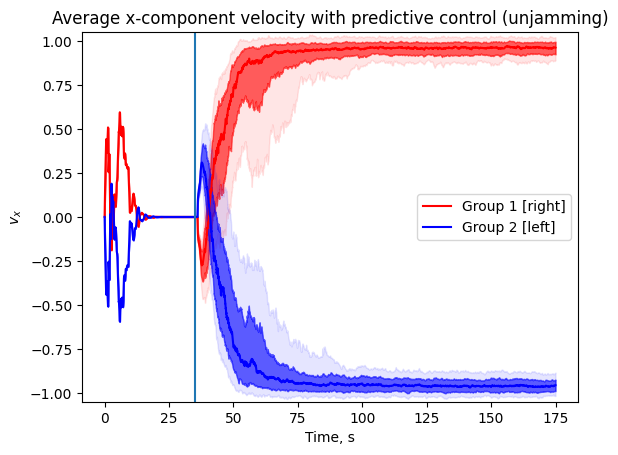

In [7]:
# Ploting velocity data
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype']='none'
from glob import glob
filestart='./40agents_withfsm_unjamming/*.pickle'
files=glob(filestart)
uData_all=[]
for file in files:
    with open(file,'rb') as f:
        uData_all.append(pickle.load(f)['uData'])

uData_all=np.array(uData_all)

uData_p_mean = np.array(uData_all).reshape(15,35001,N).mean(axis=0)
uData_p_median = np.quantile(np.array(uData_all).reshape(15,35001,N),0.5,axis=0)
uData_p_lq = np.quantile(np.array(uData_all).reshape(15,35001,N),0.25,axis=0)
uData_p_uq = np.quantile(np.array(uData_all).reshape(15,35001,N),0.75,axis=0)
uData_p_min = np.quantile(np.array(uData_all).reshape(15,35001,N),0.1,axis=0)
uData_p_max = np.quantile(np.array(uData_all).reshape(15,35001,N),0.9,axis=0)


# print(uData_p.shape)
for rep in range(1):
    # order_g1 = np.mean(uData_p[rep*35001:(rep+1)*35001, :g1], axis = 1)
    # order_g2 = np.mean(uData_p[rep*35001:(rep+1)*35001, g1:], axis = 1)
    t = np.arange(0, totalTime, deltaT)
    t=np.arange(35001)*deltaT
    
    plt.figure()
    plt.plot(t,uData_p_median[:,:g1].mean(axis=1), label = 'Group 1 [right]',color='red')
    plt.fill_between(t,uData_p_lq[:,:g1].mean(axis=1),uData_p_uq[:,:g1].mean(axis=1),alpha=0.6,color='red')
    plt.fill_between(t,uData_p_min[:,:g1].mean(axis=1),uData_p_max[:,:g1].mean(axis=1),alpha=0.1,color='red')
    plt.plot(t,uData_p_median[:,g1:].mean(axis=1), label = 'Group 2 [left]',color='blue')
    plt.fill_between(t,uData_p_lq[:,g1:].mean(axis=1),uData_p_uq[:,g1:].mean(axis=1),alpha=0.6,color='blue')
    plt.fill_between(t,uData_p_min[:,g1:].mean(axis=1),uData_p_max[:,g1:].mean(axis=1),alpha=0.1,color='blue')
    plt.ylim(-1.05,1.05)
    # plt.xlim([0, 10])
plt.title('Average x-component velocity with predictive control (unjamming)')
plt.xlabel('Time, s')
plt.ylabel(r'$v_{x}$')
plt.legend()
plt.savefig('./results_40agents/40_agents_withfsm_unjamming_35s.svg',facecolor='white',bbox_inches='tight')
plt.axvline(35)
# plt.legend()

In [14]:
files[0]

'.\\jam_length\\100_agents_withfsm_unjamming_35s_0_7083.pickle'

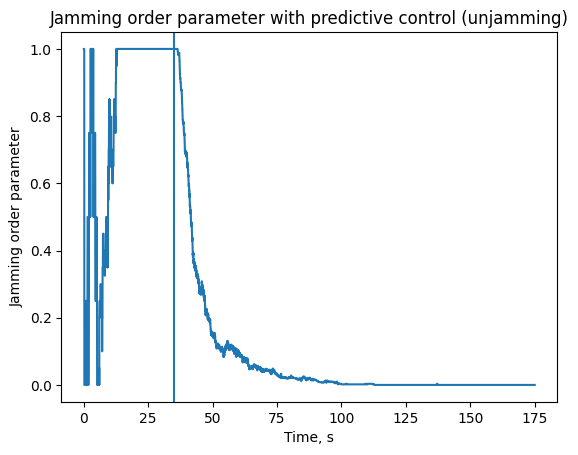

In [8]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype']='none'
# g1=40//8
uvel_g1=np.array(uData_all).reshape(15,35001,N).T[:g1]
uvel_g1=uvel_g1.transpose(0,2,1)
uvel_g1=uvel_g1.reshape(-1, uvel_g1.shape[-1]).T

uvel_g2=np.array(uData_all).reshape(15,35001,N).T[g1:]
uvel_g2=uvel_g2.transpose(0,2,1)
uvel_g2=uvel_g2.reshape(-1, uvel_g2.shape[-1]).T

num_g1=(uvel_g1<0.15).sum(axis=1)
num_g2=(uvel_g2>-0.15).sum(axis=1)
jam_op=(num_g1+num_g2)/(40*15)
plt.plot(t,jam_op)

plt.xlabel('Time, s')
plt.ylabel('Jamming order parameter')
plt.title('Jamming order parameter with predictive control (unjamming)')
plt.axvline(35)
plt.savefig('./results_40agents/40_agents_jam_op_withfsm_unjamming_35s.svg',facecolor='white',bbox_inches='tight')

In [16]:
# xData=np.array(xData).T
# xData=np.array(xData).T

filename='./images/100_withfsm'
file=files[0]
with open(file,'rb') as f:
    alldat=pickle.load(f)
    position=np.vstack([alldat['xData'][0],alldat['yData'][0]]).T
    velocity=np.vstack([alldat['uData'][0],alldat['vData'][0]]).T
    xData=alldat['xData']
    yData=alldat['yData']
    uData=alldat['uData']
    vData=alldat['vData']
    desdirs=alldat['desdirs']
    N=alldat['N']
    g1=alldat['g1']
    Lx=alldat['Lx']
for i in range(0,timeStep,125):
# for i in (14*200,14*200+1):
    plt.figure()
    for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]
        desx=desdirs[i][ag,0]
        desy=desdirs[i][ag,1]
        # dir=cmath.rect(1,dirdata[t,ag])
        plt.gca().add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue'))
        plt.arrow(xpos,ypos,vx,vy)
        plt.arrow(xpos,ypos,desx,desy,color='white',alpha=0.5)
        # plt.arrow(xpos,ypos,np.real(dir),np.imag(dir))
    plt.xlim(-1,Lx+1)
    plt.ylim(-1,Ly+1)
    plt.gca().set_aspect(1)
    plt.savefig(filename+'_prop_'+str(i)+'.png',facecolor='white')
    plt.close()

.\jam_length\150_agents_withfsm_unjamming_35s_0_4237.pickle
(35001, 150)
.\jam_length\150_agents_withfsm_unjamming_35s_10_7254.pickle
(35001, 150)
.\jam_length\150_agents_withfsm_unjamming_35s_11_6432.pickle
(35001, 150)
.\jam_length\150_agents_withfsm_unjamming_35s_12_6156.pickle
(35001, 150)
.\jam_length\150_agents_withfsm_unjamming_35s_13_9156.pickle
(35001, 150)
.\jam_length\150_agents_withfsm_unjamming_35s_14_1763.pickle
(35001, 150)
.\jam_length\150_agents_withfsm_unjamming_35s_1_3965.pickle
(35001, 150)
.\jam_length\150_agents_withfsm_unjamming_35s_2_9757.pickle
(35001, 150)
.\jam_length\150_agents_withfsm_unjamming_35s_3_1551.pickle
(35001, 150)
.\jam_length\150_agents_withfsm_unjamming_35s_4_9659.pickle
(35001, 150)
.\jam_length\150_agents_withfsm_unjamming_35s_5_7889.pickle
(35001, 150)
.\jam_length\150_agents_withfsm_unjamming_35s_6_3092.pickle
(35001, 150)
.\jam_length\150_agents_withfsm_unjamming_35s_7_4708.pickle
(35001, 150)
.\jam_length\150_agents_withfsm_unjamming_35s_

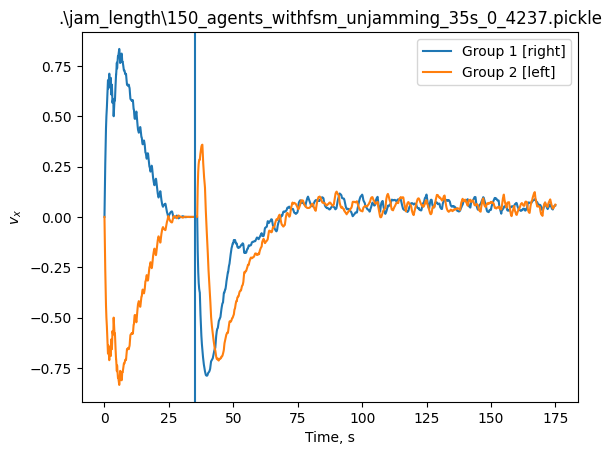

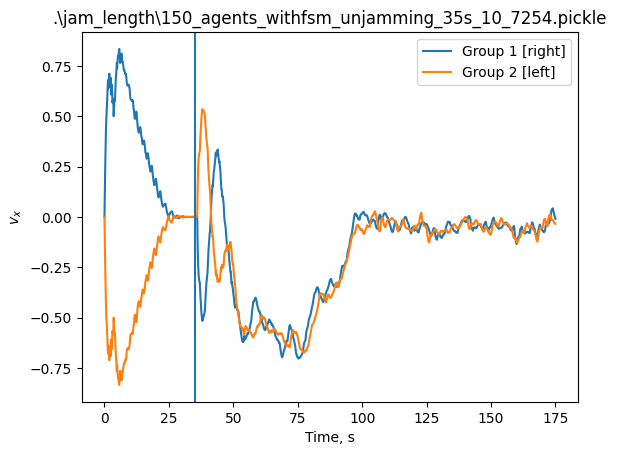

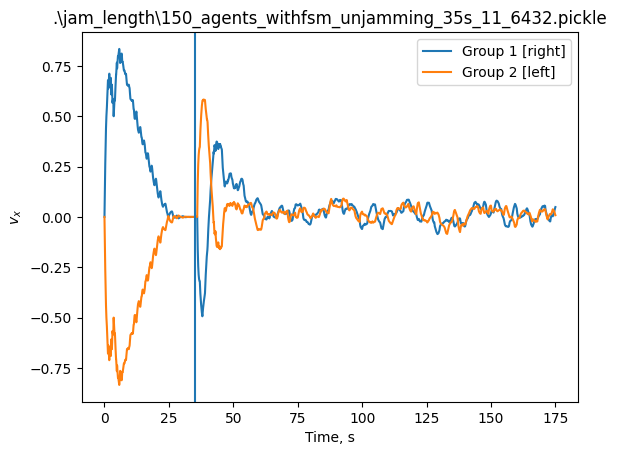

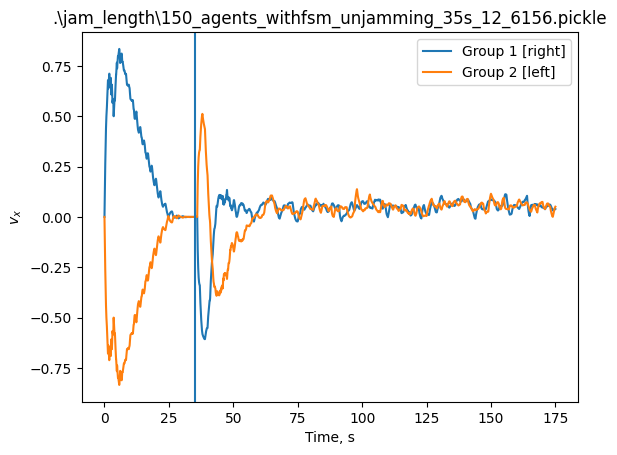

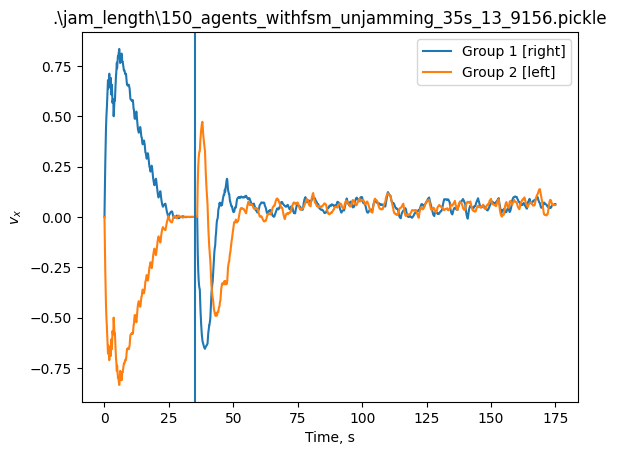

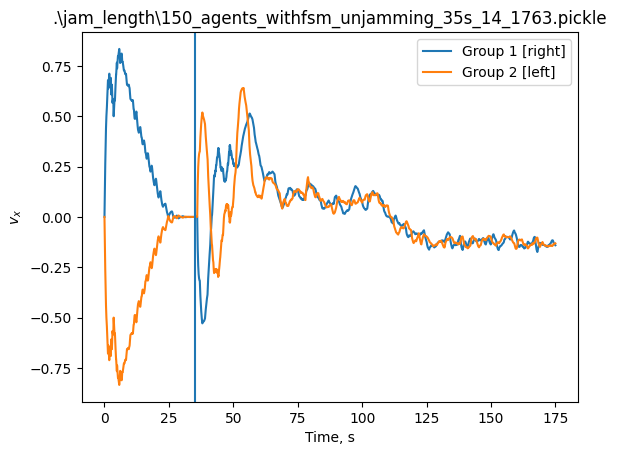

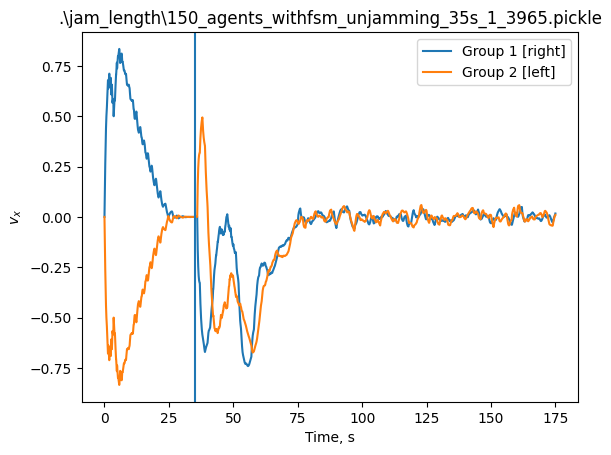

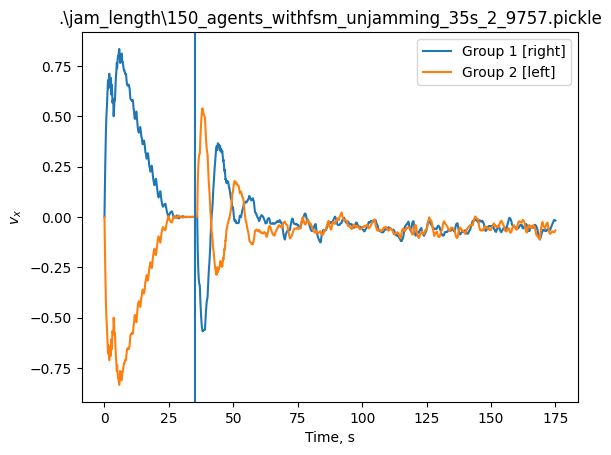

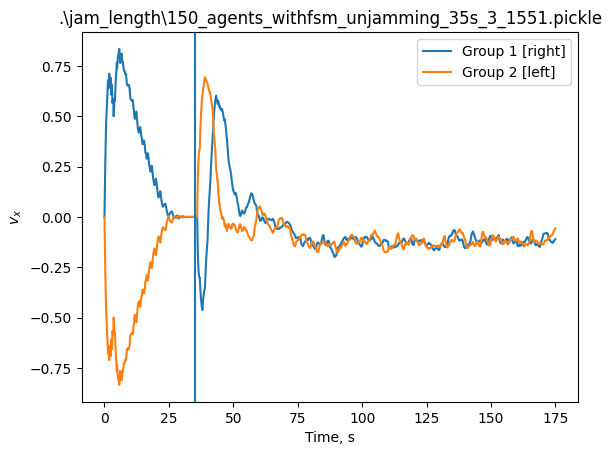

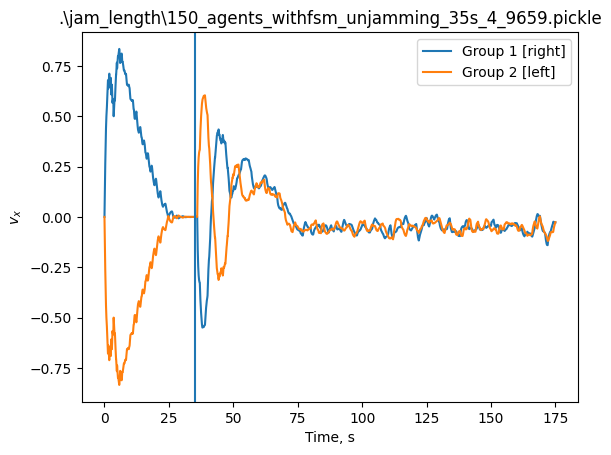

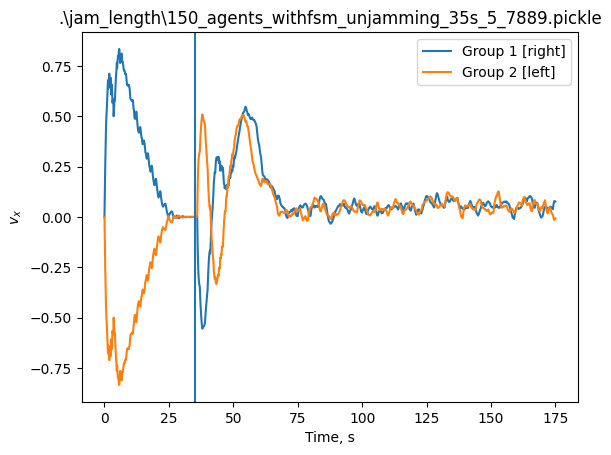

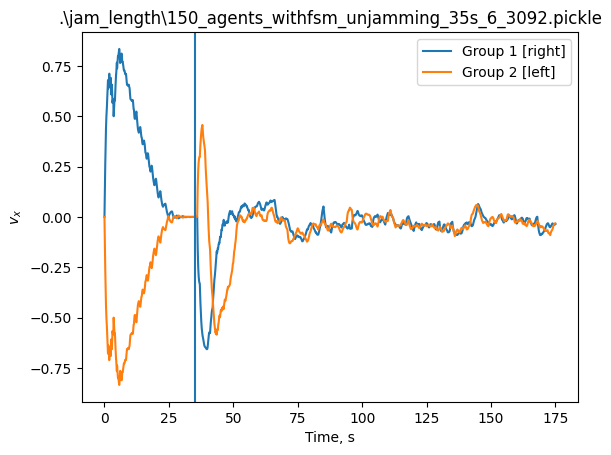

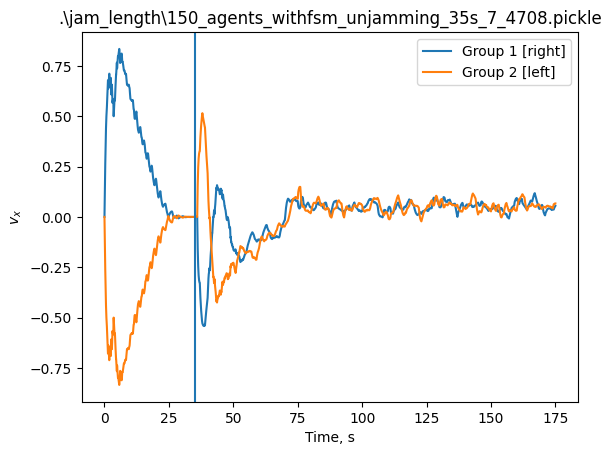

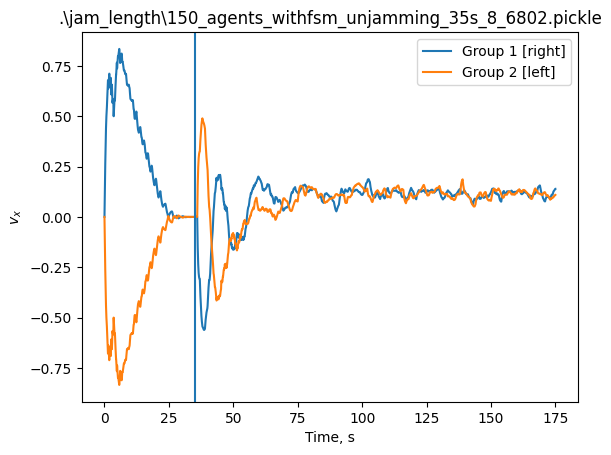

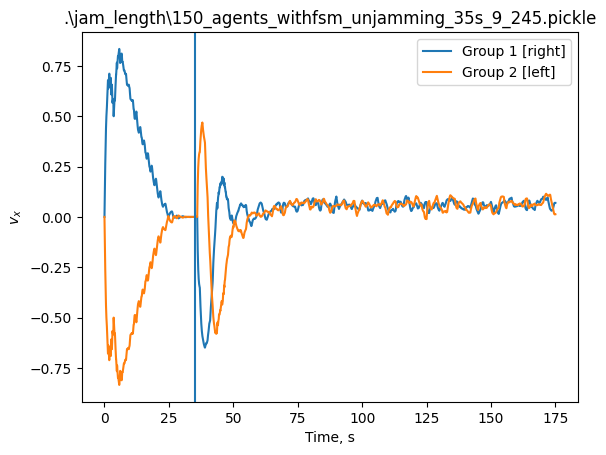

In [38]:

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype']='none'
from glob import glob
filestart='./jam_le*/150_*.pickle'
files=glob(filestart)
for file in files:
    with open(file,'rb') as f:
        alldata=pickle.load(f)
        uData=alldata['uData']
        g1=alldata['g1']
        
    plt.figure()
    print(file)
    
    uData_p = np.array(uData)
    # vData_p = np.array(vData)
    print(uData_p.shape)
    order_g1 = np.mean(uData_p[:, :g1], axis = 1)
    order_g2 = np.mean(uData_p[:, g1:], axis = 1)
    t = np.arange(0, totalTime, deltaT)
    
    
    # plt.figure()
    plt.plot(t, order_g1[:-1], label = 'Group 1 [right]')
    plt.plot(t, order_g2[:-1], label = 'Group 2 [left]')
    # plt.xlim([0, 10])
    # plt.title(file)
    plt.title(file)
    plt.xlabel('Time, s')
    plt.ylabel(r'$v_{x}$')
    # plt.xscale('log')
    plt.axvline(35)
    plt.legend()

In [30]:
files[0]

['.\\jam_length\\150_agents_withfsm_unjamming_35s_0_4237.pickle',
 '.\\jam_length\\150_agents_withfsm_unjamming_35s_1_3965.pickle',
 '.\\jam_length\\150_agents_withfsm_unjamming_35s_2_9757.pickle',
 '.\\jam_length\\150_agents_withfsm_unjamming_35s_3_1551.pickle',
 '.\\jam_length\\150_agents_withfsm_unjamming_35s_4_9659.pickle']

In [74]:
# import numpy as np
# import matplotlib.pyplot as plt
# plt.rcParams['svg.fonttype']='none'
# from glob import glob
# filestart='./jam_le*/150_*.pickle'
# files=glob(filestart)
# for file in [files[0]]:
#     with open(file,'rb') as f:
#         alldata=pickle.load(f)
#         uData=alldata['uData']
#         vData=alldata['vData']
#         xData=alldata['xData']
#         yData=alldata['yData']
#         desdirs=alldata['desdirs']
#         g1=alldata['g1']
#         Lx=alldata['Lx']
        
filename='./images/320_jam_resolve'
for i in range(0,timeStep,125):
# for i in (14*200,14*200+1):
    plt.figure()
    for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]
        desx=desdirs[i][ag,0]
        desy=desdirs[i][ag,1]
        # dir=cmath.rect(1,dirdata[t,ag])
        plt.gca().add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue'))
        plt.arrow(xpos,ypos,vx,vy)
        plt.arrow(xpos,ypos,desx,desy,color='white',alpha=0.5)
        # plt.arrow(xpos,ypos,np.real(dir),np.imag(dir))
    plt.xlim(-1,Lx+1)
    plt.ylim(-1,Ly+1)
    # plt.axhline(0)
    # plt.axhline(Ly)
    plt.gca().set_aspect(1)
    plt.savefig(filename+'_prop_'+str(i)+'.png',facecolor='white')
    plt.close()

(35001, 320)


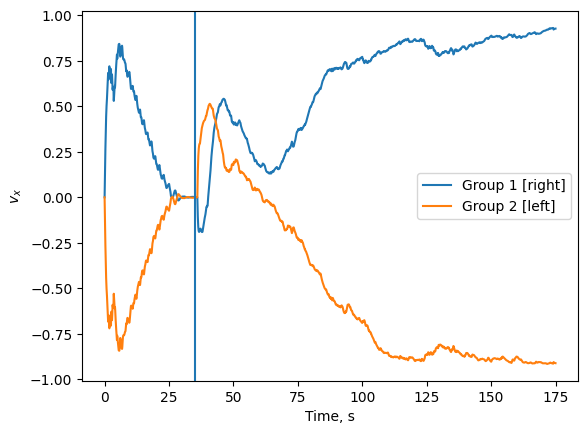

In [71]:

uData_p = np.array(uData)
# vData_p = np.array(vData)
print(uData_p.shape)
order_g1 = np.mean(uData_p[:, :g1], axis = 1)
order_g2 = np.mean(uData_p[:, g1:], axis = 1)
t = np.arange(0, totalTime, deltaT)


plt.plot(t, order_g1[:-1], label = 'Group 1 [right]')
plt.plot(t, order_g2[:-1], label = 'Group 2 [left]')
# plt.xlim([0, 10])
# plt.title(file)
# plt.title('Average x-component velocity')
plt.xlabel('Time, s')
plt.ylabel(r'$v_{x}$')
# plt.xscale('log')
plt.axvline(35)
plt.legend()

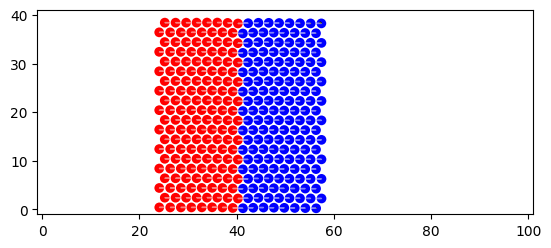

In [73]:



i=35*200
plt.figure()
for ag in range(N):
    xpos=(xData[i][ag])
    ypos=(yData[i][ag])
    vx=uData[i][ag]
    vy=vData[i][ag]
    desx=desdirs[i][ag,0]
    desy=desdirs[i][ag,1]
    # dir=cmath.rect(1,dirdata[t,ag])
    plt.gca().add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue'))
    plt.arrow(xpos,ypos,vx,vy)
    plt.arrow(xpos,ypos,desx,desy,color='white',alpha=0.5)
    # plt.arrow(xpos,ypos,np.real(dir),np.imag(dir))
plt.xlim(-1,Lx+1)
plt.ylim(-1,Ly+1)
# plt.axhline(0)
# plt.axhline(Ly)
plt.gca().set_aspect(1)

C:\Users\BalaGopal\AppData\Local\Temp\ipykernel_25924\3859642619.py:21: RuntimeWarning: Mean of empty slice.
  jam_opss.append(np.array(jam_ops).mean())


Text(0, 0.5, 'Jamming order parameter ($J$)')

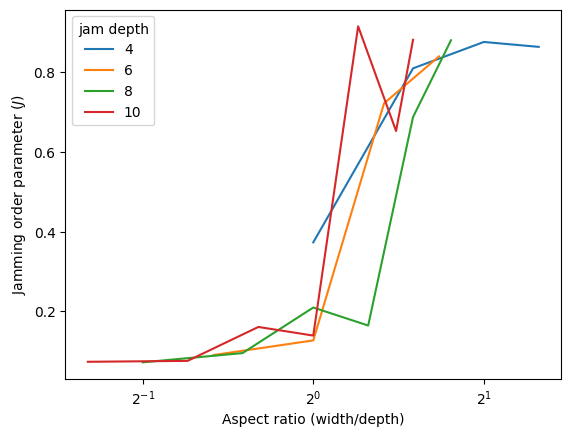

In [32]:
from glob import glob
for rows in [4,6,8]:
    jam_opss=[]
    for columns in [4,6,8,10,12,14]:
        N=rows*columns
        g1=N//2
        jam_ops=[]
        filelist=glob('./jam_width/'+str(rows)+'width'+str(N)+'*.pickle')
        for file in filelist:
            with open(file,'rb') as f:
                alldata=pickle.load(f)
            uData=np.array(alldata['uData'])
            # plt.figure()
            # plt.plot(uData[:,:g1].mean(axis=1))
            # plt.plot(uData[:,g1:].mean(axis=1))
            # plt.title(file)
            num_g1=(uData[7000:,:g1]<0.15).sum()
            num_g2=(uData[7000:,g1:N]>-0.15).sum()
            jam_op=(num_g1+num_g2)/(N*(timeStep-7000))
            jam_ops.append(jam_op)
        jam_opss.append(np.array(jam_ops).mean())
    plt.plot(np.array([4,6,8,10,12,14])/rows,jam_opss,label=rows)

rows=10
jam_opss=[]
for columns in [4,6,8,10,12,14,15]:
    N=rows*columns
    g1=N//2
    jam_ops=[]
    filelist=glob('./jam_length/'+str(N)+'*.pickle')
    for file in filelist:
        with open(file,'rb') as f:
            alldata=pickle.load(f)
        uData=np.array(alldata['uData'])
        # plt.figure()
        # plt.plot(uData[:,:g1].mean(axis=1))
        # plt.plot(uData[:,g1:].mean(axis=1))
        # plt.title(file)
        num_g1=(uData[7000:,:g1]<0.15).sum()
        num_g2=(uData[7000:,g1:N]>-0.15).sum()
        jam_op=(num_g1+num_g2)/(N*(timeStep-7000))
        jam_ops.append(jam_op)
    jam_opss.append(np.array(jam_ops).mean())
plt.plot(np.array([4,6,8,10,12,14,15])/rows,jam_opss,label=rows)

plt.xscale('log',base=2)
plt.legend(title='jam depth')
plt.xlabel('Aspect ratio (width/depth)')
plt.ylabel('Jamming order parameter ($J$)')

In [16]:
filelist=glob('./jam_width/'+str(4)+'width'+str(16)+'*.pickle')
file=filelist[1]
with open(file,'rb') as f:
    alldata=pickle.load(f)
    xData=alldata['xData']
    yData=alldata['yData']
    uData=alldata['uData']
    vData=alldata['vData']
    desdirs=alldata['desdirs']

N=16
g1=8
Lx=20
Ly=int(19*4/10)
filename='./images/16jamresolve'
for i in range(0,timeStep,125):
# for i in (14*200,14*200+1):
    plt.figure()
    for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]
        desx=desdirs[i][ag,0]
        desy=desdirs[i][ag,1]
        # dir=cmath.rect(1,dirdata[t,ag])
        plt.gca().add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue'))
        plt.arrow(xpos,ypos,vx,vy)
        plt.arrow(xpos,ypos,desx,desy,color='white',alpha=0.5)
        # plt.arrow(xpos,ypos,np.real(dir),np.imag(dir))
    plt.xlim(-1,Lx+1)
    plt.ylim(-1,Ly+1)
    # plt.axhline(0)
    # plt.axhline(Ly)
    plt.gca().set_aspect(1)
    plt.savefig(filename+'_prop_'+str(i)+'.png',facecolor='white')
    plt.close()

In [ ]:
Lx=2.5*